# Basic

In [1]:
from IPython.display import Image

## Metrics
### Expected MSE
$$E\big[(y_0 - \hat{f}(x_0))^2\big] = \operatorname{Var}(\hat{f}(x_0)) + \big[\operatorname{Bias}(\hat{f}(x_0))\big]^2 + \operatorname{Var}(\epsilon)$$
- Used for **continuous targets**. 
- **Variance**: Variation we get by using different training data sets. Related to overfitting.
- $\text{Var}(\epsilon)$ = Lower error bound; irreducible error.
- **Bias**: Error between the learning model and the true function. 
- Ideally, we want *low* variance (consistent) and *low* bias (accurate).

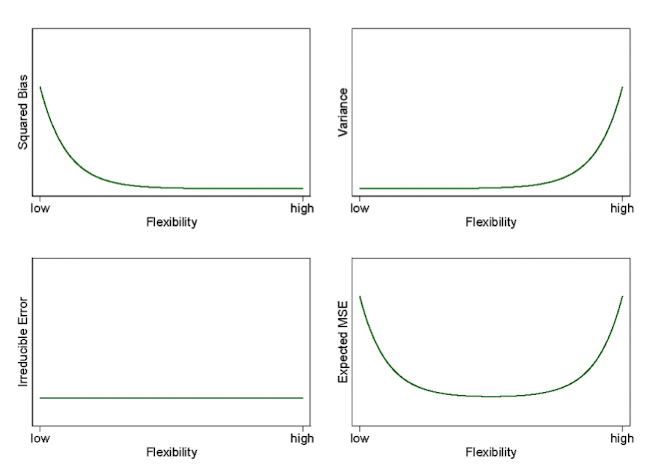

In [ ]:
Image("../data/Basic/MSE-breakdown.png")

### Accuracy
|              | Predicted True | Predicted False |
|--------------|:--------------:|:---------------:|
| Actual True  | TP             | FN              |
| Actual False | FP             | TN              |
- Used for **Categorical problems.**
- Refers to the percentage of correctly identified observations. 


$$\frac{\text{TP + TN}}{n}, n=\text{Total Number of Observations}$$

$$\frac{1}{n}\sum^n_{i=1} I(y_i=\hat{y_i})$$

#### Sensitivity (True Positive Ratio)
$$\frac{\text{TP}}{\text(TP+FN)}$$
- % of true positives correctly being identified. 
  - Common usages:To find the % of adverse events. 

#### Specificity (True Negative Ratio)
$$\frac{\text{TN}}{\text(TN+FP)}$$
- $\text{False Positive Rate} = 1-\text{Specificity}$.
  - Common usages (false positive rate): % of patients who are inaccurately assessed. 
- Ideally, we want **high sensitivity and high specificity**.

#### Multi-Class Classification
- Precision/recall must be evaluated for each class when there are multiple classes. 
- **Macroaveraging**: 
$$\frac{1}{K}\sum^K_{k=1}\text{Precision}_k$$
  - Each classes get equal weights during evaluation. By _ignoring class size_, often get dominated by frequent categories giving little weight to rare categories. 
  - _E.g._, Computing $F$-values for each 2,2 classification table and averaging the $F$-values afterwards. 
- **Microaveraging**: 
  - Aggregate all predictions first, then compute the metric. 
  - Sum all TP, FP, FN across classes. 
  - Gives more weight to large classes. 
  - Useful when we care about the overall accuracy, and when the data is imbalanced. 
  - Computing $F$ values for each 2,2 classification and averaging the $F$-values afterwards. Hence, compute the metric for each class, then take the simple average. 
  - _E.g.,_ Pooling all the 2,2 tables into a single 2,2 table and computing $F$-values based on the pooled tbable. 

### ROC
- Stands for **Receiver Operator Characteristics**. 
- Can simultaneously display **sensitivity** (TPR) and **specificity** (1-specificity; FPR) across different thresholds.

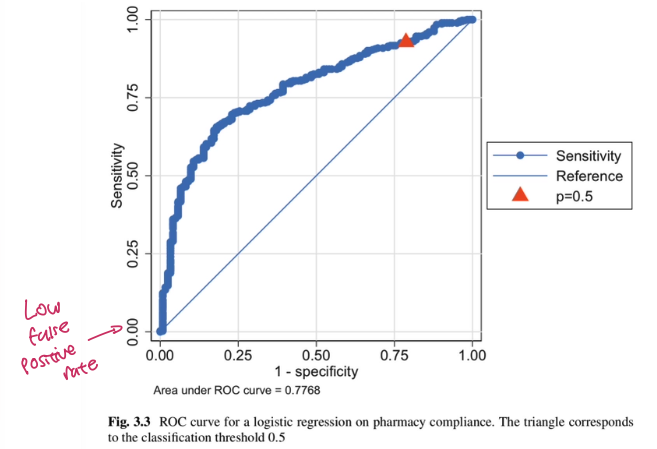

In [ ]:
Image("../data/Basic/ROC.png")

- $x$-axis depicts **False Positive Rate**, and $y$-axis depicts True Positive Rate (Recall).
  - $\text{Recall} = \frac{\text{True Positives}}{\text{All Actual Positives}}$. This is the same as *sensitivity*. 
- Close to being on the left side of the curve (with high sensitivity and 1-specificity) is preferred. 

#### Area Under Curve
- A **Value** that summarize the ROC Curve into a **single number**.
- Probability that the model ranks a random positive higher than a random negative. 
- Has a range of $0 \leq \text{AUC} \leq 1$. 
  - Close to $1.0$ means that the **classifier** is perfect. 
  - Value less $0.5$ means that the model is performing worse than random. 

#### Constructing ROC
1. Sort the records into increasing estimated probability of positive class.
2. For cutpoints $i=1,...,n$. 
  - Classify all observations below the cutpoint as $0$, and all observations greater or equal to the cutpoint as $1$. 
  - Plot the corresponding FPR vs. TPR as a point in the graph. 

##### Example
| ID | True label (y) | Predicted probability |
|----|----------------|----------------------|
| A  | 1              | 0.90                 |
| B  | 0              | 0.80                 |
| C  | 1              | 0.70                 |
| D  | 0              | 0.40                 |
| E  | 1              | 0.20                 |

If we set a **threshold** as $0.9$, 
- $A = 1$ and the other observations are $0$.
- **TP**: 1 (A)
- **FP**: 0
- **FN**: 2 (C, E)
- **TN**: 2 (B, D)
- Hence, $\text{TPR} = \frac{1}{3} = 0.33$, and $\text{FPR} = 1 - \frac{2}{2} = 0$. 
- The final point on the plot will be at $(0, 0.33)$.  

### F-Measure
$$F = \frac{2 \times \text{TP}}{2 \times \text{TP}+\text{FP}+\text{FN}}$$
$$F = 2 \times \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision}+\text{Recall}}$$
| Metric    | Description                                |
|-----------|--------------------------------------------|
| Precision | How many predicted positives are correct, $\frac{\text{TP}}{\text{TP} + \text{FP}}$.   |
| Recall    | How many actual positives are found; Same as **Sensitivity**.       |
- Used in cases when we want to avoid consequences regarding **TN**. 
  - In extremely rare cases, predicting as _no event_ will contribute to having a higher accuracy value. 
  - If always predicting _no adverse event_, then TP=$0$, and FN $> 0$. Hence F=$0$. 
- Ranges between $0 \leq \text{F} \leq 1$, with higher values being better. 
- **When to use**:
  - With imbalanced datasets (e.g., fraud detection, disease detection).
  - When both false positives and false negatives matter. 
  - When you need a single metric instead of comparing precision and recall separately.
- <span color="red">**When not to use**</span>:
  - When class balance is even and errors are symmetric. (Use RMSE or Accuracy instead)
  - When one type of error matters more. 
    - **Precision-focused**: Avoid FP.
    - **Recall-focused**: Avoid FN.

## Baseline
### Bayes Classifier
$$\Pr(Y = j \mid X)$$
- A baseline model with an assumption that test errors are minimized when each new observation is assigned to the most likely class. 
- For a new observation, choose the class with the largest probability.

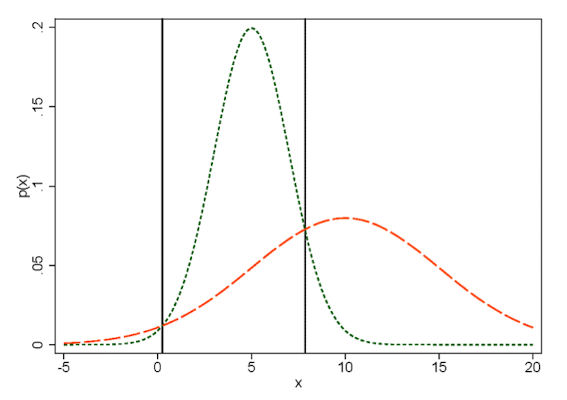

In [ ]:
Image("../data/Basic/Bayes-classifier.png")

- From the graph above, there are two noticeable boundaries where can lead to a change of membership to a new observation, one at $0$ and the other at $8$. 
- **Error rate** (For a given observation  $x$): $1-\text{max}_j\Pr(Y=j|x)$
- **Error rate** (Overall Bayes error rate): $1-E(\text{max}_j\Pr(Y=j|x))$
  - The Bayes error rate is the minimal error rate. 
  - However, in practice, Bayes error rate is never known, because the underlying functions are not known. 

## Overfitting and Underfitting
### Overfitting
- Overfitting happens when the model fits random noise of a sample rather than the generalizable relationship. 
- When does it happen?
  - When the model has too many parameters relative to the number of observations.
    - This is why advanced machine learning algorithms must be watchful towards overfitting; they are designed to have a lot of parameters. 
  - When the model is too flexible; when a model can fit a wide variety of shapes and patterns in the data.

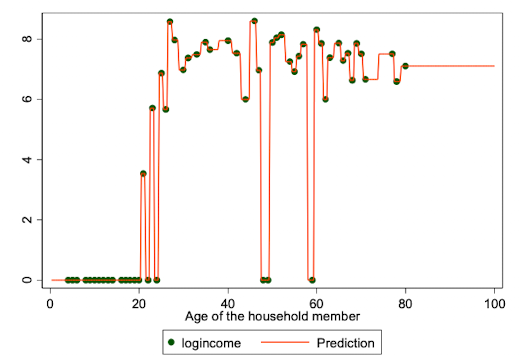

In [ ]:
Image("../data/Basic/overfitting.png")

  - As can be seen on the graph above, *overfitted model* can twist and bend very closely on data. 

## Tips
### Log Transformation
- When $y$ or any variable spans multiple magintude, it is easier to take a log of it. (E.g., $log(y)$)
  - Log transformation reduces the scale of very large values more than small ones.
  - E.g.: 
    - $y = 10$ → $log(y) = 2.3$
    - $y = 1,000,000$ → $log(y) = 13.8$
  - Hence, log transformations can shrink gaps dramatically, and *prevent large values from dominating the model.*
  - Also reduces skewness of the model and helps the model to perform better. 

### Nonlinear models
- A model is nonlinear if *parameters* ($\beta$) appear nonlinearly, not the predictors ($x_i$). For example,
$$y = \frac{\beta_1}{1+e^{\beta_2x}}$$
... is nonlinear, because you cannot seperate $\beta_1$ and $\beta_2$ into a clean linear combination. For example, _neural networks_ have their weights interacting across layers and are an example of nonlinear model. 

| | Example | Linear in coefficients? |
|---|---|---|
| Linear regression | $\beta_0 + \beta_1 x^2$ | Yes |
| Logistic regression | $\frac{1}{1+e^{-(\beta_0 + \beta_1 x)}}$ | Yes (in log odds) |
| Nonlinear model | $\beta_1 e^{\beta_2 x}$ | No |

### Linear Model
$$ y = \beta_0 + \beta_1x_1 + \beta_2x_2 + ... \beta_px_p$$
- This model above is called as **ordinary linear regression (OLR)**.
- **Least squares** are best linear *unbiaed* variance estimator, based on Gauss-Markov Theorem.
  - AKA, has the lowest variance. 
  - Refers to a specific way to esimate the coefficients $\beta$. 
  - Chooses $\hat{\beta}$ by minimizing: $\text{RSS} = \sum(y_i-\hat{y_i})^2$.

### Hyperparameter and Parameter
#### Parameter
- It is a value that is **learned** from data during training.
- _E.g.,_
  - Coefficients ($\beta$) of linear regression.
  - Weights in logistic regression and neural networks.
#### Hyperparameter
- It is set **before training**, controls how the model learns.
- _E.g.,_
  - $k$ in $k$-NN.
  - $\lambda$ in Ridge and LASSO regression.
  - `max_depth` in tree models.
  - `learning_rate` in boosting models.